# Spotify Popularity — EDA

In [1]:
import sys; sys.path.insert(0, "..")
import seaborn as sns, matplotlib.pyplot as plt
from src import config, data
df = data.add_label(data.clean(data.load_raw()))
df.shape

(89741, 18)

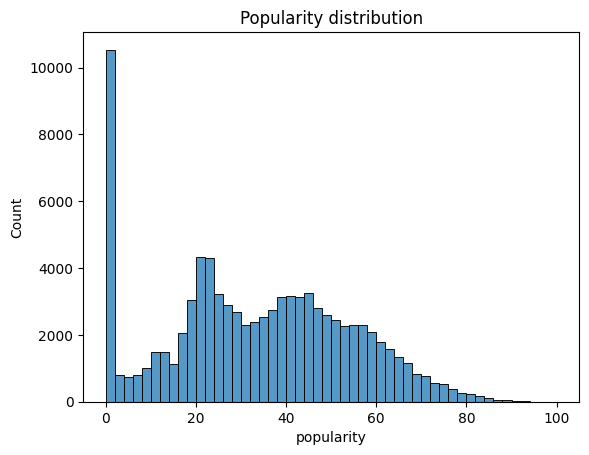

hit rate: 0.23633567711525388


In [2]:
sns.histplot(df[config.TARGET], bins=50); plt.title("Popularity distribution"); plt.show()
print("hit rate:", df[config.LABEL].mean())

In [3]:
corr = df[config.NUMERIC_FEATURES + [config.TARGET]].corr()[config.TARGET].sort_values()
corr

instrumentalness   -0.127465
speechiness        -0.047081
acousticness       -0.038847
duration_ms        -0.023119
mode               -0.016214
liveness           -0.013844
valence            -0.011526
key                 0.003432
tempo               0.007270
energy              0.013728
time_signature      0.036893
explicit            0.054902
danceability        0.064281
loudness            0.071676
popularity          1.000000
Name: popularity, dtype: float64

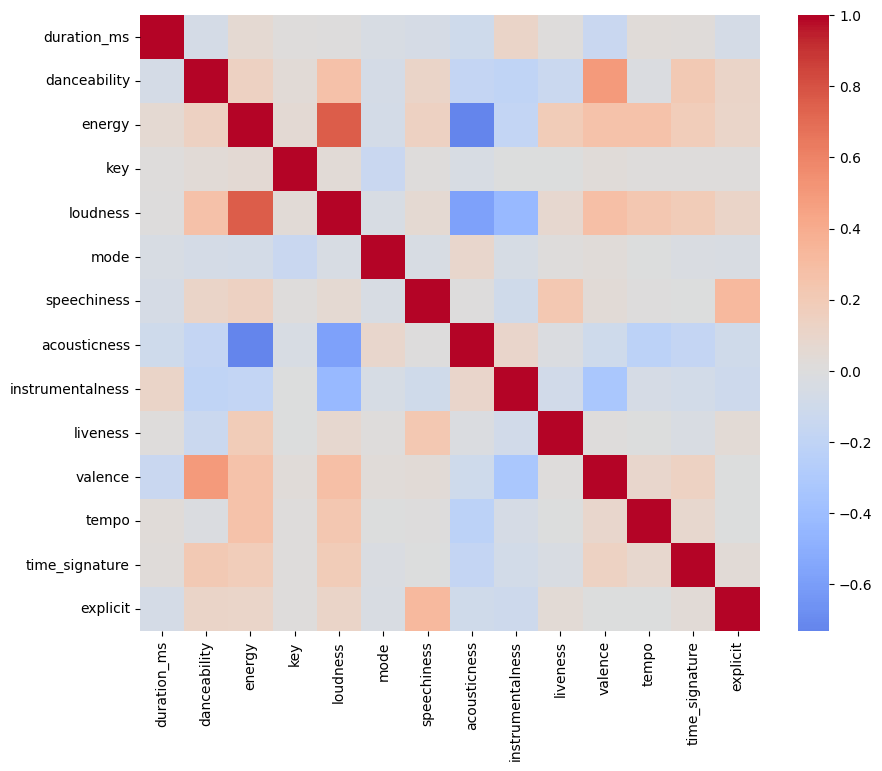

In [4]:
plt.figure(figsize=(10, 8)); sns.heatmap(df[config.NUMERIC_FEATURES].corr(), cmap="coolwarm", center=0); plt.show()

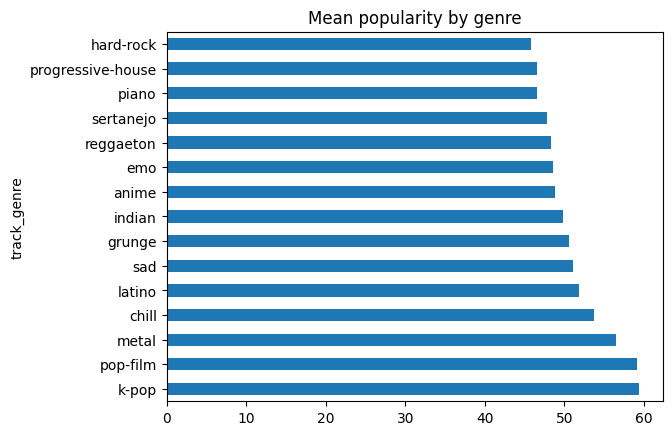

In [5]:
top = df.groupby("track_genre")[config.TARGET].mean().sort_values(ascending=False).head(15)
top.plot(kind="barh"); plt.title("Mean popularity by genre"); plt.show()